<div style="
    background:linear-gradient(135deg,#4F46E5,#6366F1);
    border-radius:16px;
    padding:26px 28px;
    margin-bottom:20px;
    box-shadow:0 6px 18px rgba(79,70,229,0.15);
    font-family:'Segoe UI', Arial, sans-serif;
">

<h1 style="
    margin:0;
    color:white;
    font-size:34px;
    font-weight:700;
    letter-spacing:0.2px;
">
Week 5 — Day 1
</h1>

<p style="
    margin:8px 0 0 0;
    color:#EEF2FF;
    font-size:20px;
    font-weight:500;
">
Unsupervised Learning & K-Means Clustering
</p>

<p style="
    margin:7px 0 0 0;
    color:#E0E7FF;
    font-size:14px;
">
Discovering hidden groups in data without predefined labels
</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 14px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 10px 0;
    font-size:23px;
">
Introduction
</h2>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
">
Not every machine learning problem comes with a known target.
In unsupervised learning, the model explores the data itself and looks for hidden patterns.
<br><br>
In this notebook, I will focus on <b>K-Means clustering</b> and use customer data to discover natural groups based on age, income, and spending behavior.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 16px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 12px 0;
    font-size:23px;
">
Learning Objectives
</h2>

<p style="
    color:#263238;
    margin:0;
    line-height:1.9;
">
By the end of this notebook, I should be able to:
<br>
• Explain the difference between supervised and unsupervised learning.<br>
• Understand how K-Means clustering works.<br>
• Prepare and scale numerical features for clustering.<br>
• Choose a suitable value of <code>k</code> using the elbow method and silhouette score.<br>
• Visualize and interpret the final clusters.
</p>

</div>

<div style="text-align:center; margin:16px 0;">
    <img src="kmeans_diagram.jpg" width="650">
</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-left:5px solid #4F46E5;
    border-radius:12px;
    padding:16px 18px;
    margin:12px 0 18px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    font-size:18px;
    margin:0 0 10px 0;
">
Today's Question
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
    font-size:15px;
">
So far, machine learning models have learned from a known target.
But what happens when the data has <b>no labels at all?</b>
<br><br>
Today I will explore how K-Means can discover natural groups in data and how the number of clusters can be selected using the elbow method and silhouette score.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 20px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 12px 0;
    font-size:23px;
">
1. Supervised vs Unsupervised Learning
</h2>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
    font-size:15px;
">
In supervised learning, the model learns from labeled data where the correct target is already known.
In unsupervised learning, there is no target column, so the goal is to discover hidden patterns or natural groups directly from the data.
</p>

<div style="
    display:grid;
    grid-template-columns:1fr 1fr;
    gap:14px;
    margin-top:16px;
">

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:11px;
    padding:15px;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 10px 0;
    font-size:16px;
">
Supervised Learning
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.8;
">
<b>Data:</b> X + y<br>
<b>Goal:</b> Predict a known target<br>
<b>Examples:</b> Classification, Regression
</p>

</div>

<div style="
    background:#EEF2FF;
    border:1px solid #C7D2FE;
    border-radius:11px;
    padding:15px;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 10px 0;
    font-size:16px;
">
Unsupervised Learning
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.8;
">
<b>Data:</b> X only<br>
<b>Goal:</b> Discover hidden structure<br>
<b>Examples:</b> Clustering, Dimensionality Reduction, Anomaly Detection
</p>

</div>

</div>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 16px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 12px 0;
    font-size:23px;
">
2. What Is Clustering?
</h2>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
    font-size:15px;
">
Clustering is an unsupervised learning technique that groups data points based on how similar they are.
<br><br>
Points inside the same cluster should be more similar to each other, while points from different clusters should be more different.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-radius:12px;
    padding:16px 18px;
    margin:10px 0 20px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 14px 0;
    font-size:17px;
">
Think of it this way
</p>

<div style="
    display:flex;
    justify-content:center;
    align-items:center;
    gap:14px;
    flex-wrap:wrap;
    color:#263238;
">

<div style="
    background:white;
    border:1px solid #DDE3F0;
    border-radius:10px;
    padding:12px 18px;
">
Unlabeled Data
</div>

<div style="
    color:#6366F1;
    font-size:22px;
    font-weight:bold;
">
→
</div>

<div style="
    background:#EEF2FF;
    border:1px solid #C7D2FE;
    border-radius:10px;
    padding:12px 18px;
">
Find Similarities
</div>

<div style="
    color:#6366F1;
    font-size:22px;
    font-weight:bold;
">
→
</div>

<div style="
    background:#E0E7FF;
    border:1px solid #C7D2FE;
    border-radius:10px;
    padding:12px 18px;
    font-weight:600;
">
Natural Groups
</div>

</div>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 14px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 12px 0;
    font-size:23px;
">
3. How Does K-Means Work?
</h2>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
    font-size:15px;
">
K-Means divides the data into a chosen number of groups called <b>clusters</b>.
Each cluster is represented by a center point called a <b>centroid</b>.
<br><br>
The algorithm keeps assigning points to their nearest centroid and updating the centroid positions until the clusters become stable.
</p>

</div>

<div style="
    background:#EEF2FF;
    border:1px solid #C7D2FE;
    border-radius:14px;
    padding:18px;
    margin:10px 0 20px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-size:17px;
    font-weight:700;
    margin:0 0 15px 0;
">
K-Means in Four Steps
</p>

<div style="
    display:flex;
    align-items:center;
    justify-content:center;
    gap:9px;
    flex-wrap:wrap;
">

<div style="
    background:#FFFFFF;
    border-radius:10px;
    padding:12px 14px;
    color:#263238;
    text-align:center;
">
<b style="color:#4F46E5;">1</b><br>
Choose K
</div>

<span style="color:#6366F1;font-size:20px;font-weight:bold;">→</span>

<div style="
    background:#FFFFFF;
    border-radius:10px;
    padding:12px 14px;
    color:#263238;
    text-align:center;
">
<b style="color:#4F46E5;">2</b><br>
Place Centroids
</div>

<span style="color:#6366F1;font-size:20px;font-weight:bold;">→</span>

<div style="
    background:#FFFFFF;
    border-radius:10px;
    padding:12px 14px;
    color:#263238;
    text-align:center;
">
<b style="color:#4F46E5;">3</b><br>
Assign Points
</div>

<span style="color:#6366F1;font-size:20px;font-weight:bold;">→</span>

<div style="
    background:#FFFFFF;
    border-radius:10px;
    padding:12px 14px;
    color:#263238;
    text-align:center;
">
<b style="color:#4F46E5;">4</b><br>
Move Centroids
</div>

<span style="color:#6366F1;font-size:20px;font-weight:bold;">↻</span>

</div>

<p style="
    color:#667085;
    margin:14px 0 0 0;
    text-align:center;
    font-size:14px;
">
Steps 3 and 4 repeat until the centroid positions stop changing significantly.
</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 20px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 14px 0;
    font-size:23px;
">
Hands-On Lab — What Are We Trying to Discover?
</h2>

<p style="
    color:#263238;
    margin:0 0 16px 0;
    line-height:1.75;
">
Now that the idea behind K-Means is clear, I will apply it to real customer data.
The analysis will follow five connected questions:
</p>

<div style="
    background:#EEF2FF;
    border-radius:10px;
    padding:14px 16px;
">

<p style="color:#263238;margin:0;line-height:2;">
<b style="color:#4F46E5;">1.</b> Is the data ready for distance-based clustering?<br>
<b style="color:#4F46E5;">2.</b> Where does the elbow suggest the best value of <code>k</code>?<br>
<b style="color:#4F46E5;">3.</b> Does the silhouette score confirm that choice?<br>
<b style="color:#4F46E5;">4.</b> What do the final clusters look like?<br>
<b style="color:#4F46E5;">5.</b> What type of customers does each cluster represent?
</p>

</div>

</div>

<div style="
    background:#4F46E5;
    border-radius:12px;
    padding:14px 18px;
    margin:18px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#FFFFFF;
    font-weight:700;
    font-size:19px;
    margin:0 0 5px 0;
">
Hands-On Step 1 — Prepare and Scale the Data
</p>

<p style="
    color:#EEF2FF;
    margin:0;
    font-size:14px;
">
Load the customer data, select the numerical features, handle missing values, and prepare the features for distance-based clustering.
</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 14px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 12px 0;
    font-size:23px;
">
4. Meet the Dataset
</h2>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
    font-size:15px;
">
For today's clustering task, I will use a customer dataset containing demographic and spending-related information.
<br><br>
The goal is to discover whether customers naturally form different groups without using any predefined labels.
</p>

</div>

<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<span style="color:#263238;">
First, I will import the required tools and load the customer dataset so I can begin exploring the data.
</span>

</div>

In [52]:
import pandas as pd
import os
os.environ["OMP_NUM_THREADS"] = "4"
df = pd.read_csv("store_customers.csv")



<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">
<span style="color:#263238;">
I will first inspect the dataset size, columns, and a few customer records before deciding which features to use for clustering.
</span>
</div>

In [30]:
df.shape

(1000, 5)

In [53]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.head()


Dataset shape: (1000, 5)

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<span style="color:#263238;">
For the first clustering experiment, I will use <b>Age</b>, <b>Annual Income</b>, and <b>Spending Score</b>.  
<code>CustomerID</code> will be excluded because it is only an identifier, while <code>Gender</code> will be kept out of the initial numeric clustering analysis.
</span>

</div>

In [32]:
features = df[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,39.0,59.9,58.0
1,34.0,48.4,37.0
2,40.0,70.5,26.0
3,47.0,81.1,30.0
4,33.0,42.1,58.0


<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-radius:10px;
    padding:13px 15px;
    margin:10px 0 18px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 8px 0;
">
Observation
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.7;
">
The clustering data now contains three numerical features: <b>Age</b>, <b>Annual Income</b>, and <b>Spending Score</b>.
<br><br>
CustomerID was removed because it is only an identifier, and Gender was excluded from the first K-Means experiment so the analysis can focus on the main numerical customer characteristics.
</p>

</div>

<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<span style="color:#263238;">
Before preparing the data for clustering, I will check the selected features for any missing values.
</span>

</div>

In [49]:
features.isnull().sum()

Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<span style="color:#263238;">
A small number of missing values were found in the selected clustering features.  
Since the dataset contains 1000 customer records and only a few rows are affected, I will remove incomplete rows before applying K-Means.
</span>

</div>

In [50]:
features = features.dropna()

print("Shape after removing missing rows:", features.shape)
print("\nMissing values:")
print(features.isnull().sum())

Shape after removing missing rows: (984, 3)

Missing values:
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 14px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 12px 0;
    font-size:23px;
">
5. Why Does Scaling Matter?
</h2>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
    font-size:15px;
">
K-Means groups points using distance. If one feature has much larger values than the others, it can have more influence on the clustering result.
<br><br>
To give the selected features a more comparable scale, I will standardize them before applying K-Means.
</p>

</div>

<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<span style="color:#263238;">
Now that the missing values have been removed, I will use <b>StandardScaler</b> to standardize the three selected features before applying K-Means.
</span>

</div>

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[ 0.0030337 ,  0.0895807 ,  0.76675619],
       [-0.37011189, -0.31197816, -0.27817225],
       [ 0.07766282,  0.45971321, -0.82551571],
       [ 0.60006665,  0.82984572, -0.62648173],
       [-0.44474101, -0.53196258,  0.76675619]])

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-radius:10px;
    padding:13px 15px;
    margin:10px 0 18px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 8px 0;
">
Observation
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.7;
">
The three customer features are now standardized, so K-Means can compare them on a more similar scale instead of allowing one feature to dominate because of its numerical range.
</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:12px;
    padding:14px 16px;
    margin:12px 0 10px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0;
    font-size:17px;
">
Before vs After Scaling
</p>

</div>

<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<span style="color:#263238;">
To make the effect of scaling easier to see, I will compare the feature ranges before and after standardization.
</span>

</div>

In [36]:
before_scaling = features.agg(["min", "max"]).T

after_scaling = pd.DataFrame(
    scaled_features,
    columns=features.columns
).agg(["min", "max"]).T

print("Before Scaling:")
display(before_scaling)

print("After Scaling:")
display(after_scaling.round(2))

Before Scaling:


,min,max
Age,18.0,80.0
Annual Income (k$),15.0,144.1
Spending Score (1-100),1.0,92.0


After Scaling:


,min,max
Age,-1.56,3.07
Annual Income (k$),-1.47,3.04
Spending Score (1-100),-2.07,2.46


<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-radius:10px;
    padding:13px 15px;
    margin:10px 0 18px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 8px 0;
">
Observation
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.7;
">
Before scaling, the selected features have different numerical ranges. After standardization, their values are placed on a more comparable scale.
<br><br>
This is important because K-Means uses distance when assigning customers to clusters.
</p>

</div>

<div style="
    background:#4F46E5;
    border-radius:12px;
    padding:14px 18px;
    margin:18px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#FFFFFF;
    font-weight:700;
    font-size:19px;
    margin:0 0 5px 0;
">
Hands-On Step 2 — Find the Best K with the Elbow Method
</p>

<p style="
    color:#EEF2FF;
    margin:0;
    font-size:14px;
">
Test values of <code>k</code> from 1 to 10, compare their inertia, and use the elbow plot to identify the strongest cluster candidate.
</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 14px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 12px 0;
    font-size:23px;
">
6. Choosing K with the Elbow Method
</h2>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
    font-size:15px;
">
K-Means needs the number of clusters <b>k</b> to be chosen before training.
<br><br>
The elbow method tests several values of <code>k</code> and compares their inertia. I will look for the point where the decrease starts to slow down, creating an elbow-like shape.
</p>

</div>

<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<span style="color:#263238;">
I will test values of <b>k from 1 to 10</b> and store the inertia for each one.
Then I will plot the results to look for the elbow point.
</span>

</div>

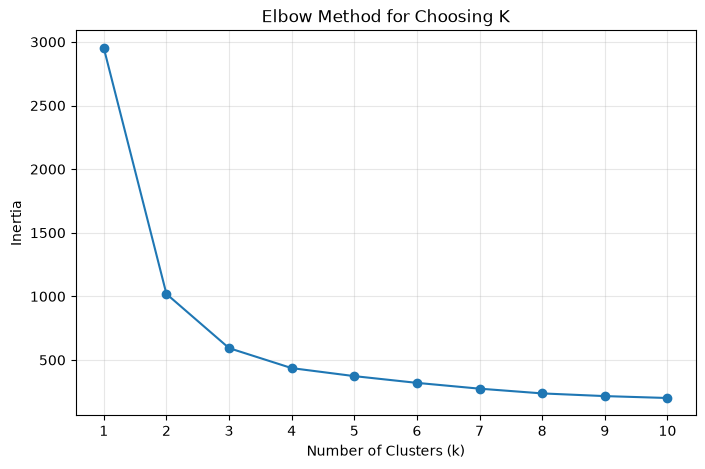

In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL"
)
inertias = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_features)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)

plt.show()

<div style="
    background:#EEF2FF;
    border:1px solid #C7D2FE;
    border-radius:12px;
    padding:14px 16px;
    margin:12px 0 18px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 8px 0;
    font-size:17px;
">
How to Read This Plot
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
">
At first, increasing <code>k</code> makes the inertia drop very quickly, which means the clusters are improving a lot.
<br><br>
Around <b>k = 3</b>, the curve starts to bend and the improvement becomes much smaller.
This bend is called the <b>elbow</b>.
<br><br>
So, <b>k = 3</b> looks like the strongest first choice, while <b>k = 4</b> can also be tested as another candidate.
</p>

</div>

<p style="
    color:#667085;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:14px;
    margin-top:-8px;
">
Think of the elbow as the point where adding more clusters stops giving a big improvement.
</p>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-left:4px solid #6366F1;
    border-radius:10px;
    padding:13px 15px;
    margin:10px 0 16px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 8px 0;
">
Next Question
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.7;
">
The elbow plot gives us a strong visual clue, but the bend is not perfectly sharp.
So how can we confirm whether <code>k = 3</code> or <code>k = 4</code> creates better-separated clusters?
</p>

</div>

<div style="
    background:#4F46E5;
    border-radius:12px;
    padding:14px 18px;
    margin:18px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#FFFFFF;
    font-weight:700;
    font-size:19px;
    margin:0 0 5px 0;
">
Hands-On Step 3 — Confirm K with the Silhouette Score
</p>

<p style="
    color:#EEF2FF;
    margin:0;
    font-size:14px;
">
Compare the strongest elbow candidates using the silhouette score and choose the value of <code>k</code> that gives better-separated clusters.
</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 14px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 12px 0;
    font-size:23px;
">
7. Confirming K with the Silhouette Score
</h2>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
    font-size:15px;
">
The elbow method suggested <code>k = 3</code> and <code>k = 4</code> as the strongest candidates.
<br><br>
To compare them more objectively, I will calculate the silhouette score for both values. A higher score means the clusters are more clearly separated.
</p>

</div>

<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<span style="color:#263238;">
The elbow method suggested <b>k = 3</b> and <b>k = 4</b> as possible choices.
Now I will compare their silhouette scores to see which value creates better-separated clusters.
</span>

</div>

In [42]:
from sklearn.metrics import silhouette_score

for k in [3, 4]:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_features)

    score = silhouette_score(scaled_features, labels)

    print("k =", k, "| Silhouette Score =", round(score, 3))

k = 3 | Silhouette Score = 0.484
k = 4 | Silhouette Score = 0.381


<div style="
    background:#EEF2FF;
    border:1px solid #C7D2FE;
    border-radius:12px;
    padding:15px 17px;
    margin:12px 0 18px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 10px 0;
    font-size:17px;
">
Elbow vs Silhouette — Do They Agree?
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
">
The elbow plot suggested that <code>k = 3</code> was the strongest candidate.
<br><br>
The silhouette score confirms this result:
<br>
<b>k = 3 → 0.484</b><br>
<b>k = 4 → 0.381</b>
<br><br>
Since <code>k = 3</code> has the higher silhouette score, I will use <b>3 clusters</b> for the final K-Means model.
</p>

</div>

<div style="
    background:#4F46E5;
    border-radius:12px;
    padding:14px 18px;
    margin:18px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#FFFFFF;
    font-weight:700;
    font-size:19px;
    margin:0 0 5px 0;
">
Hands-On Step 4 — Fit and Visualize the Final K-Means Model
</p>

<p style="
    color:#EEF2FF;
    margin:0;
    font-size:14px;
">
Train the final K-Means model using the selected value of <code>k</code>, assign cluster labels, and visualize the discovered groups in a 2D scatter plot.
</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 14px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 12px 0;
    font-size:23px;
">
8. Build the Final K-Means Model
</h2>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
    font-size:15px;
">
Both the elbow method and the silhouette score pointed to <code>k = 3</code>.
Now I can build the final K-Means model and assign each customer to one of the three discovered clusters.
</p>

</div>

<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<span style="color:#263238;">
Now that <b>k = 3</b> has been selected, I will train the final K-Means model and assign each customer to one of the three clusters.
</span>

</div>

In [44]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(scaled_features)

features_with_clusters = features.copy()
features_with_clusters["Cluster"] = cluster_labels

features_with_clusters.head()

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,39.0,59.9,58.0,2
1,34.0,48.4,37.0,2
2,40.0,70.5,26.0,0
3,47.0,81.1,30.0,0
4,33.0,42.1,58.0,2


<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-radius:12px;
    padding:15px 17px;
    margin:10px 0 18px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 10px 0;
    font-size:17px;
">
What Happened Here?
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.8;
">
<b>1.</b> The final model was created with <code>3 clusters</code>.
<br><br>
<b>2.</b> K-Means grouped the scaled customer data.
<br><br>
<b>3.</b> Each customer received a cluster label: <code>0</code>, <code>1</code>, or <code>2</code>.
<br><br>
<b>4.</b> The cluster labels were added back to the original feature values so the groups can be interpreted more easily.
</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 14px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 12px 0;
    font-size:23px;
">
9. What Do the Clusters Look Like?
</h2>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
    font-size:15px;
">
The model has assigned every customer to one of three clusters.
Now I want to visualize these groups and see whether they form clear patterns.
<br><br>
For this 2D view, I will use <b>Annual Income</b> and <b>Spending Score</b>, since they provide an intuitive way to compare customer behavior.
</p>

</div>

<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<span style="color:#263238;">
I will visualize the customer groups using <b>Annual Income</b> and <b>Spending Score</b>.
The cluster colors were learned using all three selected features, while this plot gives a simple 2D view of the result.
</span>

</div>

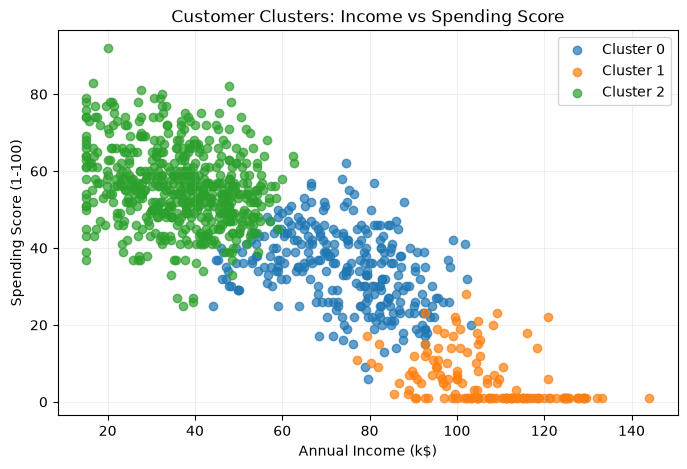

In [45]:
plt.figure(figsize=(8, 5))

for cluster in sorted(features_with_clusters["Cluster"].unique()):
    group = features_with_clusters[
        features_with_clusters["Cluster"] == cluster
    ]

    plt.scatter(
        group["Annual Income (k$)"],
        group["Spending Score (1-100)"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters: Income vs Spending Score")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-radius:12px;
    padding:15px 17px;
    margin:10px 0 18px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 10px 0;
    font-size:17px;
">
What Can We See?
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
">
The three clusters show noticeably different customer patterns.
<br><br>

<b>Cluster 2</b> contains many customers with lower to moderate income and relatively higher spending scores.
<br><br>

<b>Cluster 1</b> is concentrated among higher-income customers with very low spending scores.
<br><br>

<b>Cluster 0</b> lies mostly between the other two groups, with moderate spending and medium-to-high income.
<br><br>

Because K-Means was trained using <b>three features</b>, this 2D plot shows only one view of the clustering. Age may also help separate customers that appear close together in this figure.
</p>

</div>

<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<span style="color:#263238;">
Next, I will convert the cluster centroids back to the original feature scale so they can be displayed correctly on the customer scatter plot.
</span>

</div>

In [46]:
centroids = scaler.inverse_transform(
    final_kmeans.cluster_centers_
)

centroids

array([[ 42.58075601,  73.7257732 ,  34.82130584],
       [ 65.40714286, 106.52      ,   5.86428571],
       [ 30.35804702,  36.25714286,  55.97649186]])

<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<span style="color:#263238;">
Now I will plot the customer clusters again and add the centroids as <b>X marks</b> to show the center of each group.
</span>

</div>

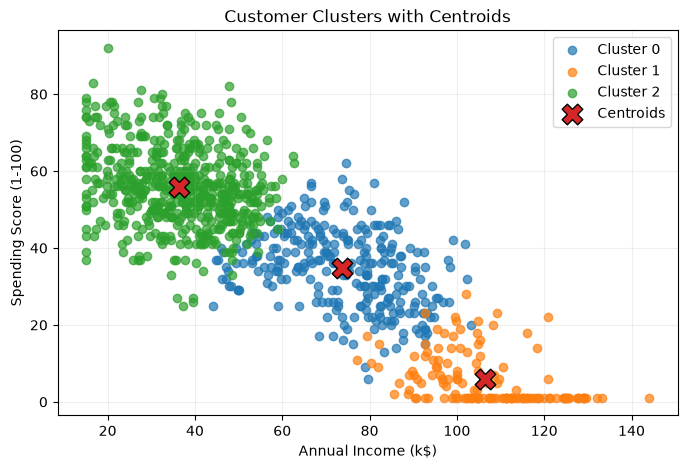

In [47]:
plt.figure(figsize=(8, 5))

for cluster in sorted(features_with_clusters["Cluster"].unique()):
    group = features_with_clusters[
        features_with_clusters["Cluster"] == cluster
    ]

    plt.scatter(
        group["Annual Income (k$)"],
        group["Spending Score (1-100)"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.scatter(
    centroids[:, 1],
    centroids[:, 2],
    marker="X",
    s=220,
    edgecolors="black",
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters with Centroids")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

<div style="
    background:#EEF2FF;
    border:1px solid #C7D2FE;
    border-radius:12px;
    padding:14px 16px;
    margin:10px 0 18px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 8px 0;
">
What Do the X Marks Mean?
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.7;
">
Each <b>X</b> represents the centroid of one cluster.
It is the average position of the customers assigned to that group.
<br><br>
K-Means repeatedly moves these centroids until the cluster assignments become stable.
</p>

</div>

<div style="
    background:#4F46E5;
    border-radius:12px;
    padding:14px 18px;
    margin:18px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#FFFFFF;
    font-weight:700;
    font-size:19px;
    margin:0 0 5px 0;
">
Hands-On Step 5 — Interpret the Clusters
</p>

<p style="
    color:#EEF2FF;
    margin:0;
    font-size:14px;
">
Compare the average characteristics of each cluster and describe what type of customers each group represents.
</p>

</div>

<div style="
    background:#EEF2FF;
    border-left:4px solid #4F46E5;
    border-radius:10px;
    padding:12px 14px;
    margin:10px 0 12px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<span style="
    color:#263238;
    line-height:1.7;
">
Now I will calculate the average <b>Age</b>, <b>Annual Income</b>, and <b>Spending Score</b> for each cluster.
This will help me understand what makes each customer group different.
</span>

</div>

In [48]:
cluster_profile = (
    features_with_clusters
    .groupby("Cluster")
    .mean()
    .round(2)
)

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.60,73.80,34.78
1,65.41,106.52,5.86
2,30.37,36.29,55.96


<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:12px;
    padding:14px 16px;
    margin:12px 0 10px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0;
    font-size:17px;
">
Interpreting the Cluster Profiles
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-radius:12px;
    padding:15px 17px;
    margin:10px 0 18px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 10px 0;
    font-size:17px;
">
Cluster Profile
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.8;
">
<b>Cluster 0</b> contains middle-aged customers, with an average age of about <b>42.6</b>. Their average income is around <b>73.8k</b>, while their spending score is relatively moderate at about <b>34.8</b>.
<br><br>

<b>Cluster 1</b> contains the oldest customers, with an average age of about <b>65.4</b>. They also have the highest average income at about <b>106.5k</b>, but the lowest spending score at only about <b>5.9</b>.
<br><br>

<b>Cluster 2</b> contains the youngest customers, with an average age of about <b>30.4</b>. Their average income is lower at about <b>36.3k</b>, but they have the highest spending score at about <b>56.0</b>.
</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 18px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 14px 0;
    font-size:23px;
">
10. Creative Insight — Customer Personas
</h2>

<p style="
    color:#263238;
    margin:0 0 16px 0;
    line-height:1.75;
    font-size:15px;
">
The cluster numbers themselves do not explain much.
To make the results easier to understand, I will describe each group using the patterns found in its average values.
</p>

<div style="
    display:grid;
    grid-template-columns:repeat(3,1fr);
    gap:14px;
">

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-radius:11px;
    padding:15px;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 8px 0;
">
Cluster 0
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.7;
">
<b>Moderate Spenders</b><br><br>
Age: ~42.6<br>
Income: ~73.8k<br>
Spending: ~34.8
</p>

</div>

<div style="
    background:#EEF2FF;
    border:1px solid #C7D2FE;
    border-radius:11px;
    padding:15px;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 8px 0;
">
Cluster 1
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.7;
">
<b>High Income, Low Spending</b><br><br>
Age: ~65.4<br>
Income: ~106.5k<br>
Spending: ~5.9
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-radius:11px;
    padding:15px;
">

<p style="
    color:#4F46E5;
    font-weight:700;
    margin:0 0 8px 0;
">
Cluster 2
</p>

<p style="
    color:#263238;
    margin:0;
    line-height:1.7;
">
<b>Young Active Spenders</b><br><br>
Age: ~30.4<br>
Income: ~36.3k<br>
Spending: ~56.0
</p>

</div>

</div>

<p style="
    color:#667085;
    margin:14px 0 0 0;
    font-size:14px;
">
These labels are descriptive interpretations of the cluster averages, not predefined customer categories.
</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 14px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 12px 0;
    font-size:23px;
">
11.Final Findings
</h2>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
">
The analysis started with unlabeled customer data and gradually revealed three distinct customer groups.
<br><br>
The elbow method first suggested <code>k = 3</code>, and the silhouette score supported the same choice with a higher score of <b>0.484</b> compared with <b>0.381</b> for <code>k = 4</code>.
<br><br>
After fitting the final model, the cluster profiles showed meaningful differences in customer age, income, and spending behavior.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE3F0;
    border-radius:14px;
    padding:18px 20px;
    margin:12px 0 14px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 12px 0;
    font-size:23px;
">
12. One Limitation to Keep in Mind
</h2>

<p style="
    color:#263238;
    margin:0;
    line-height:1.75;
">
K-Means works well when clusters are reasonably compact and separated, but real customer groups may not always have this shape.
<br><br>
The result also depends on the selected features and the value of <code>k</code>, so cluster interpretation should always be supported by the data rather than the cluster number alone.
</p>

</div>

<div style="
    background:linear-gradient(135deg,#4F46E5,#6366F1);
    border-radius:14px;
    padding:18px 20px;
    margin:14px 0 20px 0;
    font-family:'Segoe UI', Arial, sans-serif;
">

<h2 style="
    color:#FFFFFF;
    margin:0 0 12px 0;
    font-size:23px;
">
Day 1 Takeaway
</h2>

<p style="
    color:#EEF2FF;
    margin:0;
    line-height:1.8;
">
Today I learned how K-Means can discover hidden groups in unlabeled data.
I prepared and scaled the customer features, used the elbow method and silhouette score to choose <b>k = 3</b>, built the final clustering model, and interpreted the resulting customer groups.
<br><br>
The main lesson is that clustering is not only about assigning labels. The real value comes from understanding what makes each discovered group different.
</p>

</div>